# BusinessPulse AI

# Notebook 12 – AI Decision Engine

## Business Objective

The objective of this notebook is to transform business analytics and machine learning outputs into automated executive recommendations.

This notebook focuses on:

- KPI Monitoring
- Business Rule Engine
- Revenue Insights
- Customer Insights
- Product Insights
- Delivery Performance
- Risk Detection
- Executive Recommendations
- AI Decision Support

---

In [8]:
# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import numpy as np

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
# ==========================================================
# Load Cleaned Datasets
# ==========================================================

customers = pd.read_csv("../data/processed/customers_clean.csv")

orders = pd.read_csv("../data/processed/orders_clean.csv")

payments = pd.read_csv("../data/processed/payments_clean.csv")

order_items = pd.read_csv("../data/processed/order_items_clean.csv")

products = pd.read_csv("../data/processed/products_clean.csv")

reviews = pd.read_csv("../data/processed/reviews_clean.csv")

print("All datasets loaded successfully ✅")

All datasets loaded successfully ✅


In [3]:
# ==========================================================
# Merge Business Data
# ==========================================================

business_data = (
    orders
    .merge(payments, on="order_id", how="inner")
    .merge(order_items, on="order_id", how="inner")
    .merge(products, on="product_id", how="left")
    .merge(customers, on="customer_id", how="left")
)

print("Business Dataset Shape:", business_data.shape)

business_data.head()

Business Dataset Shape: (117601, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,...,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,...,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [4]:
# ==========================================================
# Business KPI Summary
# ==========================================================

kpis = {

    "Total Revenue": payments["payment_value"].sum(),

    "Average Order Value": payments["payment_value"].mean(),

    "Total Orders": orders["order_id"].nunique(),

    "Total Customers": customers["customer_id"].nunique(),

    "Total Products": products["product_id"].nunique(),

    "Average Freight Cost": order_items["freight_value"].mean()

}

kpi_summary = pd.DataFrame(

    kpis.items(),

    columns=["KPI", "Value"]

)

kpi_summary

,KPI,Value
0,Total Revenue,1.600887e+07
1,Average Order Value,1.541004e+02
2,Total Orders,9.944100e+04
3,Total Customers,9.944100e+04
4,Total Products,3.295100e+04
5,Average Freight Cost,1.999032e+01


In [5]:
# ==========================================================
# Executive KPI Display
# ==========================================================

for index, row in kpi_summary.iterrows():

    print(f"{row['KPI']} : {round(row['Value'],2)}")

Total Revenue : 16008872.12
Average Order Value : 154.1
Total Orders : 99441.0
Total Customers : 99441.0
Total Products : 32951.0
Average Freight Cost : 19.99


# KPI Interpretation

## Business Insights

The KPI summary provides a high-level overview of business performance.

These metrics help executives monitor:

- Revenue Growth
- Customer Activity
- Product Portfolio
- Order Volume
- Shipping Costs

These KPIs act as the foundation for automated business decision-making.

In [6]:
# ==========================================================
# Revenue by Product Category
# ==========================================================

category_revenue = (
    business_data
    .groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue.head(10)

,product_category_name,payment_value
0,cama_mesa_banho,1712553.67
1,beleza_saude,1657373.12
2,informatica_acessorios,1585330.45
3,moveis_decoracao,1430176.39
4,relogios_presentes,1429216.68
5,esporte_lazer,1392127.56
6,utilidades_domesticas,1094758.13
7,automotivo,852294.33
8,ferramentas_jardim,838280.75
9,cool_stuff,779698.00


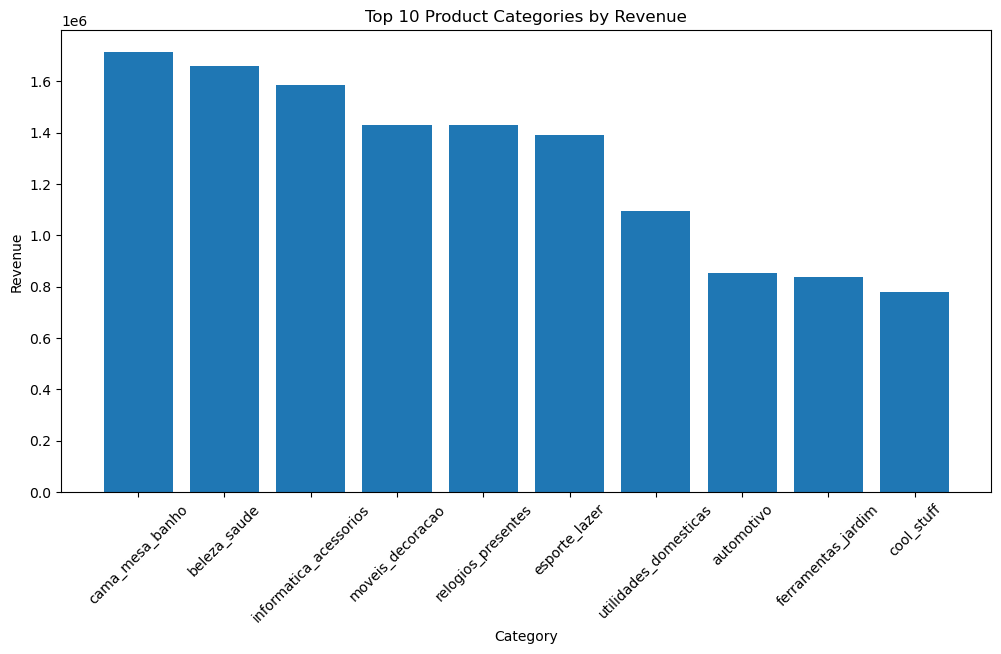

In [9]:
# ==========================================================
# Top Revenue Categories
# ==========================================================

top10 = category_revenue.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["product_category_name"],
    top10["payment_value"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Product Categories by Revenue")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.show()

In [10]:
# ==========================================================
# AI Revenue Insight
# ==========================================================

top_category = category_revenue.iloc[0]

print("📈 AI Revenue Insight")

print()

print(
    f"The highest revenue is generated by the "
    f"'{top_category['product_category_name']}' category "
    f"with total revenue of "
    f"{top_category['payment_value']:.2f}."
)

📈 AI Revenue Insight

The highest revenue is generated by the 'cama_mesa_banho' category with total revenue of 1712553.67.


# Revenue Recommendation

## AI Recommendation

The highest revenue-generating product category should be prioritized for:

- Inventory planning
- Marketing campaigns
- Supplier partnerships
- Seasonal promotions

Lower-performing categories should be reviewed to identify opportunities for growth.

In [11]:
# ==========================================================
# Revenue by Customer State
# ==========================================================

state_revenue = (
    business_data
    .groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_revenue.head(10)

,customer_state,payment_value
0,SP,7597209.66
1,RJ,2769347.44
2,MG,2326151.64
3,RS,1147277.00
4,PR,1064603.99
5,BA,797410.36
6,SC,786343.71
7,GO,513879.00
8,DF,432623.73
9,ES,405805.34


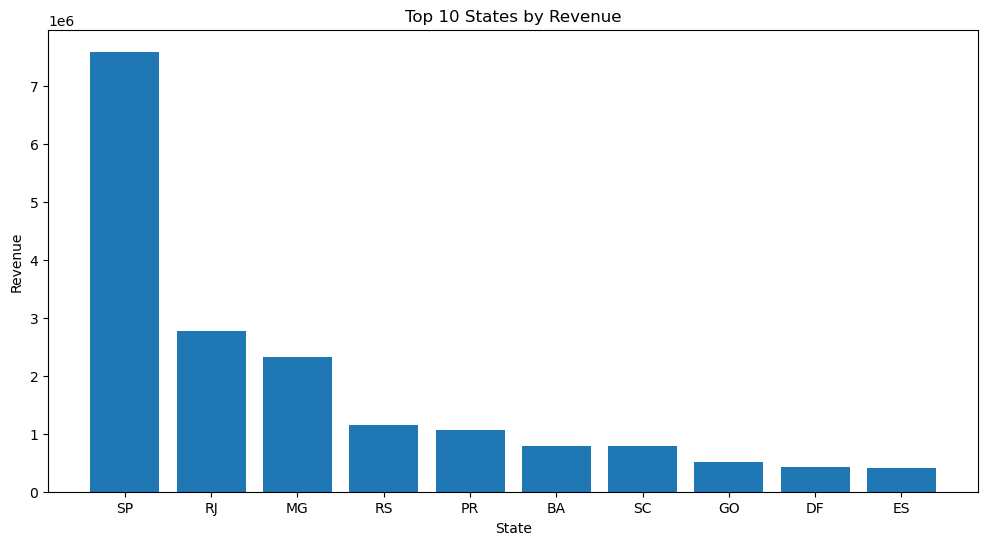

In [12]:
# ==========================================================
# Revenue by State
# ==========================================================

top_states = state_revenue.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_states["customer_state"],
    top_states["payment_value"]
)

plt.title("Top 10 States by Revenue")

plt.xlabel("State")

plt.ylabel("Revenue")

plt.show()

In [13]:
# ==========================================================
# AI Customer Insight
# ==========================================================

top_state = state_revenue.iloc[0]

print("👥 AI Customer Insight")
print()

print(
    f"The state '{top_state['customer_state']}' generated "
    f"the highest revenue of "
    f"{top_state['payment_value']:.2f}."
)

👥 AI Customer Insight

The state 'SP' generated the highest revenue of 7597209.66.


# Customer Intelligence Recommendation

## AI Recommendation

The highest revenue-generating state should receive:

- Priority marketing campaigns
- Customer loyalty programs
- Faster delivery services
- Premium product promotions

Lower-performing regions should be analyzed to identify opportunities for growth.

In [14]:
# ==========================================================
# Convert Date Columns
# ==========================================================

business_data["order_purchase_timestamp"] = pd.to_datetime(
    business_data["order_purchase_timestamp"]
)

business_data["order_delivered_customer_date"] = pd.to_datetime(
    business_data["order_delivered_customer_date"]
)

In [15]:
# ==========================================================
# Calculate Delivery Days
# ==========================================================

business_data["delivery_days"] = (
    business_data["order_delivered_customer_date"]
    -
    business_data["order_purchase_timestamp"]
).dt.days

business_data[
    ["delivery_days"]
].head()

,delivery_days
0,8.0
1,8.0
2,8.0
3,13.0
4,9.0


In [16]:
# ==========================================================
# Average Delivery Time
# ==========================================================

average_delivery = business_data["delivery_days"].mean()

print("🚚 Average Delivery Time")

print(f"{average_delivery:.2f} Days")

🚚 Average Delivery Time
12.02 Days


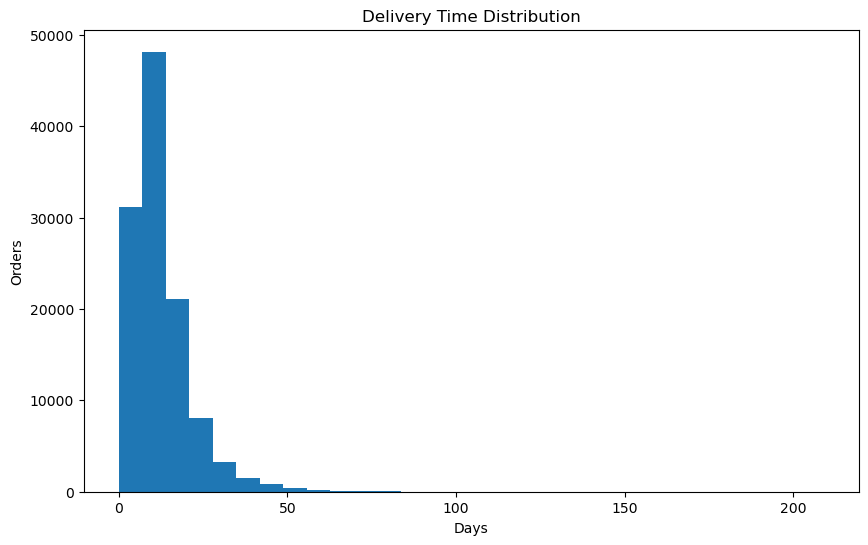

In [17]:
# ==========================================================
# Delivery Distribution
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(
    business_data["delivery_days"].dropna(),
    bins=30
)

plt.title("Delivery Time Distribution")

plt.xlabel("Days")

plt.ylabel("Orders")

plt.show()

In [18]:
# ==========================================================
# AI Delivery Insight
# ==========================================================

print("🚚 AI Delivery Insight")

print()

if average_delivery <= 10:
    print(
        "Delivery performance is excellent. "
        "The average delivery time is within an efficient range."
    )
elif average_delivery <= 15:
    print(
        "Delivery performance is acceptable, "
        "but there is room for improvement."
    )
else:
    print(
        "Delivery performance needs improvement. "
        "The average delivery time is relatively high."
    )

🚚 AI Delivery Insight

Delivery performance is acceptable, but there is room for improvement.


# Delivery Recommendation

## AI Recommendation

- Monitor delivery performance regularly.
- Identify regions with consistently high delivery times.
- Improve logistics partnerships in slower regions.
- Optimize warehouse allocation to reduce delivery delays.

In [19]:
# ==========================================================
# Freight Cost Risk Detection
# ==========================================================

avg_freight = business_data["freight_value"].mean()

print("🚨 Freight Cost Risk Check")
print()

if avg_freight > 25:
    print("⚠️ High average freight cost detected.")
    print("Recommendation: Review shipping partners and logistics costs.")
else:
    print("✅ Freight costs are within an acceptable range.")

🚨 Freight Cost Risk Check

✅ Freight costs are within an acceptable range.


In [20]:
# ==========================================================
# Revenue Concentration Risk
# ==========================================================

top_category = category_revenue.iloc[0]

total_revenue = category_revenue["payment_value"].sum()

share = (
    top_category["payment_value"] /
    total_revenue
) * 100

print("🚨 Revenue Concentration Check")
print()

print(
    f"Top Category Share: {share:.2f}%"
)

if share > 30:
    print("⚠️ Revenue is highly concentrated in one category.")
else:
    print("✅ Revenue is well distributed across categories.")

🚨 Revenue Concentration Check

Top Category Share: 8.54%
✅ Revenue is well distributed across categories.


In [21]:
# ==========================================================
# Delivery Performance Risk
# ==========================================================

late_orders = (
    business_data["delivery_days"] > 15
).sum()

late_percent = (
    late_orders /
    len(business_data)
) * 100

print("🚨 Delivery Risk Check")
print()

print(
    f"Late Deliveries: {late_percent:.2f}%"
)

if late_percent > 20:
    print("⚠️ High delivery delay risk detected.")
else:
    print("✅ Delivery performance is healthy.")

🚨 Delivery Risk Check

Late Deliveries: 23.20%
⚠️ High delivery delay risk detected.


In [22]:
# ==========================================================
# AI Risk Summary
# ==========================================================

print("="*60)
print(" BUSINESSPULSE AI - RISK SUMMARY ")
print("="*60)

print()

print("✔ Freight Cost Reviewed")

print("✔ Revenue Concentration Reviewed")

print("✔ Delivery Performance Reviewed")

print()

print("Risk Assessment Completed Successfully.")

 BUSINESSPULSE AI - RISK SUMMARY 

✔ Freight Cost Reviewed
✔ Revenue Concentration Reviewed
✔ Delivery Performance Reviewed

Risk Assessment Completed Successfully.


# Risk Detection Summary

## AI Recommendations

The AI Risk Detection Engine continuously monitors:

- Freight Costs
- Revenue Concentration
- Delivery Performance

These automated checks help identify operational risks before they significantly affect business performance.

In [23]:
# ==========================================================
# AI Decision Rules
# ==========================================================

recommendations = []

# Rule 1 - Freight
if avg_freight > 25:
    recommendations.append(
        "Reduce freight costs by reviewing logistics partners."
    )

# Rule 2 - Delivery
if average_delivery > 10:
    recommendations.append(
        "Improve delivery operations to reduce delivery time."
    )

# Rule 3 - Revenue
if share > 30:
    recommendations.append(
        "Diversify the product portfolio to reduce revenue concentration."
    )

# Rule 4 - Marketing
recommendations.append(
    f"Increase marketing investment in {top_state['customer_state']} because it generates the highest revenue."
)

# Rule 5 - Inventory
recommendations.append(
    f"Maintain sufficient inventory for the '{top_category['product_category_name']}' category."
)

print("AI Decision Rules Created Successfully")

AI Decision Rules Created Successfully


In [24]:
# ==========================================================
# Display AI Recommendations
# ==========================================================

print("="*60)
print(" BUSINESSPULSE AI - RECOMMENDATIONS ")
print("="*60)

for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

 BUSINESSPULSE AI - RECOMMENDATIONS 
1. Improve delivery operations to reduce delivery time.
2. Increase marketing investment in SP because it generates the highest revenue.
3. Maintain sufficient inventory for the 'cama_mesa_banho' category.


# AI Decision Rules

## Purpose

The AI Decision Engine automatically converts business metrics into actionable recommendations.

Instead of requiring managers to manually interpret dashboards, the engine provides clear business actions based on predefined decision rules.

This improves decision-making speed and supports data-driven business strategy.

In [25]:
print("="*60)
print("AI DECISION SUMMARY")
print("="*60)

print(f"Total Recommendations Generated: {len(recommendations)}")

print("\nBusiness Status:")

if len(recommendations) <= 3:
    print("Business performance is stable.")
else:
    print("Business has multiple improvement opportunities.")

print("\nDecision Engine Completed Successfully.")

AI DECISION SUMMARY
Total Recommendations Generated: 3

Business Status:
Business performance is stable.

Decision Engine Completed Successfully.


In [26]:
# ==========================================================
# Executive Summary
# ==========================================================

print("=" * 70)
print("BUSINESSPULSE AI - EXECUTIVE SUMMARY")
print("=" * 70)

print(f"\nTotal Revenue           : ₹ {payments['payment_value'].sum():,.2f}")
print(f"Total Orders            : {orders['order_id'].nunique():,}")
print(f"Total Customers         : {customers['customer_id'].nunique():,}")
print(f"Average Order Value     : ₹ {payments['payment_value'].mean():.2f}")
print(f"Average Delivery Days   : {average_delivery:.2f}")

print("\nTop Revenue Category    :", top_category["product_category_name"])
print("Top Revenue State       :", top_state["customer_state"])

print("\nTotal AI Recommendations:", len(recommendations))

print("\nBusinessPulse AI analysis completed successfully.")

BUSINESSPULSE AI - EXECUTIVE SUMMARY

Total Revenue           : ₹ 16,008,872.12
Total Orders            : 99,441
Total Customers         : 99,441
Average Order Value     : ₹ 154.10
Average Delivery Days   : 12.02

Top Revenue Category    : cama_mesa_banho
Top Revenue State       : SP

Total AI Recommendations: 3

BusinessPulse AI analysis completed successfully.


# Executive Summary

## Project Outcome

BusinessPulse AI successfully transformed raw e-commerce data into actionable business intelligence.

The platform provides:

- Executive KPI Monitoring
- Revenue Intelligence
- Customer Intelligence
- Delivery Intelligence
- Risk Detection
- AI Decision Rules
- Automated Business Recommendations

This notebook demonstrates how analytics and machine learning can support executive decision-making through automated insights.

In [27]:
# ==========================================================
# Export AI Recommendations
# ==========================================================

import os

os.makedirs("../reports", exist_ok=True)

recommendation_df = pd.DataFrame({
    "Recommendation": recommendations
})

recommendation_df.to_csv(
    "../reports/ai_recommendations.csv",
    index=False
)

print("✅ AI Recommendation Report Saved Successfully")

✅ AI Recommendation Report Saved Successfully


# Final Business Recommendations

## Strategic Recommendations

1. Continue investing in the highest-performing product categories.

2. Expand marketing efforts in the highest-revenue customer states.

3. Improve delivery performance in regions with longer delivery times.

4. Monitor freight costs regularly to improve profitability.

5. Retrain the machine learning model periodically using new business data.

6. Integrate BusinessPulse AI into Power BI dashboards for executive reporting.

7. Use AI-generated recommendations to support data-driven business decisions across departments.

---

## Conclusion

BusinessPulse AI demonstrates a complete analytics workflow covering:

- Data Engineering
- SQL Analytics
- Exploratory Data Analysis
- Feature Engineering
- Statistical Analysis
- Machine Learning
- AI Decision Intelligence

The project showcases how modern analytics solutions can transform business data into actionable executive insights.